In [3]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df['Annual Income (k$)'] = df['total_bill'] * 10
df['Spending Score (1-100)'] = df['tip'] * 10

df.head()

,total_bill,tip,sex,smoker,day,time,size,Annual Income (k$),Spending Score (1-100)
0,16.99,1.01,Female,No,Sun,Dinner,2,169.9,10.1
1,10.34,1.66,Male,No,Sun,Dinner,3,103.4,16.6
2,21.01,3.50,Male,No,Sun,Dinner,3,210.1,35.0
3,23.68,3.31,Male,No,Sun,Dinner,2,236.8,33.1
4,24.59,3.61,Female,No,Sun,Dinner,4,245.9,36.1


In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

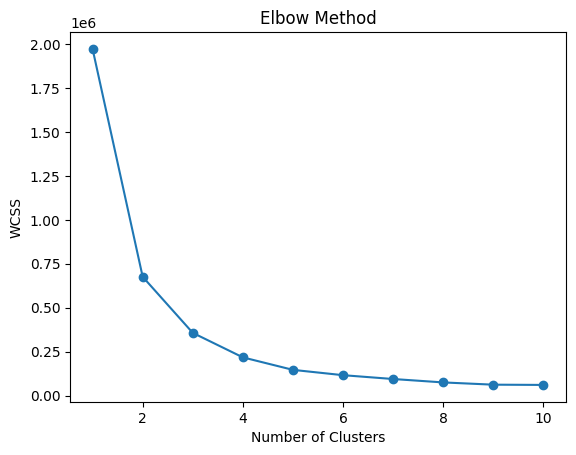

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

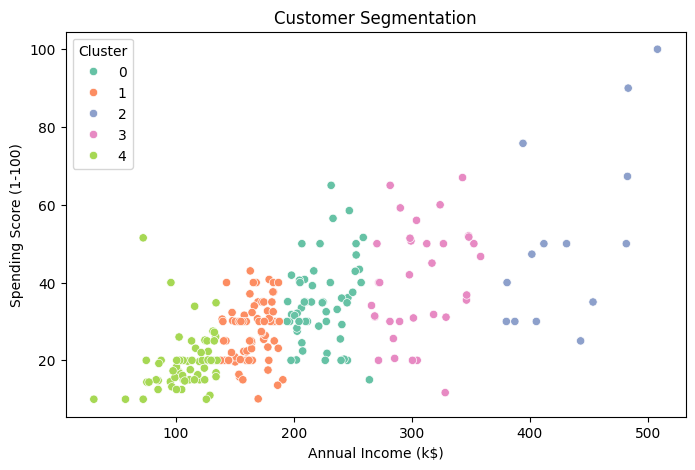

In [8]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    data=df
)

plt.title("Customer Segmentation")
plt.show()

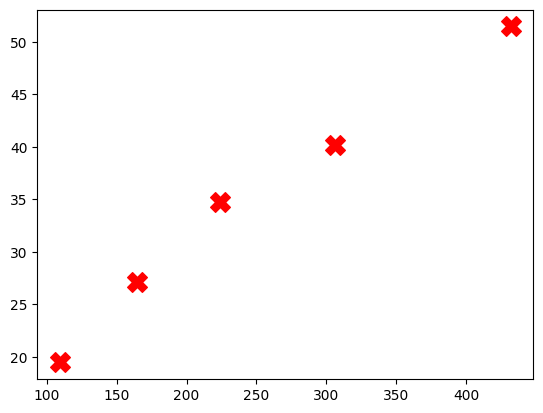

In [9]:
centers = kmeans.cluster_centers_

plt.scatter(centers[:,0], centers[:,1], c='red', s=200, marker='X')
plt.show()

In [10]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,223.601818,34.776364
1,164.837838,27.166216
2,431.771429,51.457143
3,306.158824,40.214706
4,109.364179,19.479104


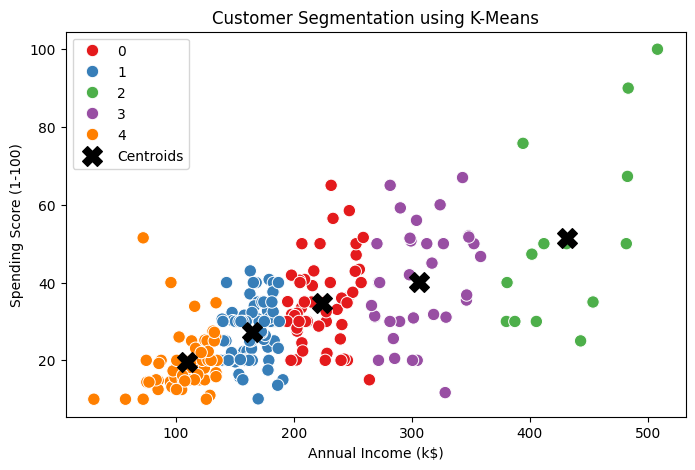

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=80
)

# centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker='X', label='Centroids')

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

## 📊 Key Insights

- Customers are grouped into 5 distinct segments based on income and spending behavior.

- High income & high spending customers are the most valuable segment.

- Some high-income customers spend less, indicating potential for targeted marketing.

- Low income but high spending customers show impulsive buying behavior.

- Clustering helps businesses design personalized marketing strategies.

In [18]:
plt.savefig("customer_segmentation.png")

<Figure size 640x480 with 0 Axes>